<a href="https://colab.research.google.com/github/Narender-9/Machine-Learning-Lab/blob/main/Task%206/PCA_%26_Clustering_Models%5BPostLab%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Explained Variance Ratio:
[0.40662092 0.27577972]

Total Variance Explained:
0.6824006399224629

Cluster Counts:
Cluster
1    635
2    144
0    112
Name: count, dtype: int64

PCA and Clustering Results:
        PC1       PC2  Cluster
0  0.016321 -0.821471        1
1 -0.008293  0.948664        2
2 -0.653896 -0.538567        1
3 -0.043272  0.527074        1
4 -0.897816 -0.064039        1


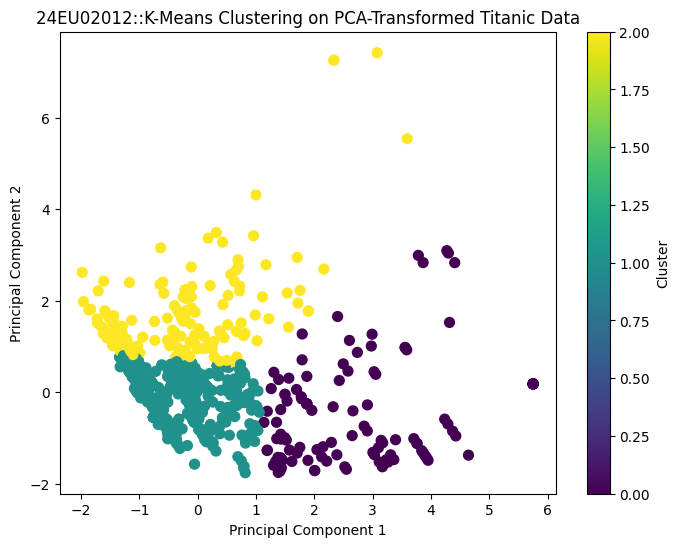

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Select numerical features
features = ["age", "fare", "sibsp", "parch"]

X = titanic[features].copy()

# Handle missing values
X = X.fillna(X.median())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

pca_df["Cluster"] = kmeans.fit_predict(X_pca)

print("\nCluster Counts:")
print(pca_df["Cluster"].value_counts())

# Display first few results
print("\nPCA and Clustering Results:")
print(pca_df.head())

# Visualize clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("24EU02012::K-Means Clustering on PCA-Transformed Titanic Data")
plt.colorbar(label="Cluster")
plt.show()